In [7]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')
sys.path.append('./SALSA-CLRS/')

import torch
from model.GINE import GINE

from loguru import logger
from baselines.core.models.encoder import Encoder
from baselines.core.models.decoder import Decoder
from baselines.core.loss import CLRSLoss
from salsaclrs import specs

device = torch.device('cuda')

K = 10000
task = 'bfs'
split = 'val'
circuit_algorithm = 'greedy'
score_method = 'weight_grad'
prune = True

epochs = range(200)
checkpoint_dir = f'checkpoints/new_all_tasks_distributed_GINE_l1_schedule_lr=0.001_eta=0.0001_weight_decay=0.1_lambda_hint=1.0_lambda_hidden=0.1_schedule=False_batch_size=32_seed=0_hidden_dim=128'
checkpoint_stem = f'model_in_progress_'
circuit_checkpoint = f'{checkpoint_stem}199'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from EncodeProcessDecode import EncodeProcessDecode
algorithms = ['bfs', 'dfs', 'dijkstra', 'mst_prim', 'bellman_ford', 'articulation_points', 'bridges']
output_types = {
    'bfs' : 'pointer',
    'dfs' : 'pointer',
    'dijkstra' : 'pointer',
    'mst_prim' : 'pointer',
    'bellman_ford' : 'pointer',
    'articulation_points' : 'mask',
    'bridges' : 'edge_mask',
}
accuracy_types = {
    'bfs' : 'node_accuracy',
    'dfs' : 'node_accuracy',
    'dijkstra' : 'node_accuracy',
    'mst_prim' : 'node_accuracy',
    'bellman_ford' : 'node_accuracy',
    'articulation_points' : 'node_accuracy',
    'bridges' : 'edge_accuracy',
}
logger.disable('baselines.core.models.encoder')
logger.disable('baselines.core.models.decoder')

hidden_dim = 128
encoders = torch.nn.ModuleDict({
    task : Encoder(specs=specs.SPECS[task]) for task in algorithms
})

decoders = torch.nn.ModuleDict({
    task : Decoder(specs=specs.SPECS[task], 
                   hidden_dim = hidden_dim * 2,
                   no_hint=False) for task in algorithms
})

for encoder in encoders.values():
    encoder.to(device)
for decoder in decoders.values():
    decoder.to(device)
processor = GINE(3*128, 128, 2, 128, edge_dim=1, aggr='max')
processor.to(device)
model = EncodeProcessDecode(encoders, decoders, processor, device=device)
model_state = torch.load(f'{checkpoint_dir}/{circuit_checkpoint}.pt', map_location=device)
model.load_state_dict(model_state)

<All keys matched successfully>

In [3]:
from SALSACLRSComputationGraph import SALSACLRSComputationGraph

G = SALSACLRSComputationGraph(model, special_modules=['convs.0.lin', 'convs.1.lin'])
G.add_module('convs.0.lin', processor.convs[0].lin,
            module_inputs='edge_attr',
            module_outputs=0,
            layer=0)
G.add_module('convs.1.lin', processor.convs[1].lin,
            module_inputs='edge_attr',
            module_outputs=2,
            layer=0)
G.correct_layers()
print(G.number_of_edges())

G_save_string = f'G_scores_new_{circuit_checkpoint}.pt'
G_scores = torch.load(f'scored_computation_graphs/{G_save_string}', weights_only=False)
for edge, data in G_scores.items():
    G.add_edge(*edge, **data)
print(f'Loaded existing scored computation graph from scored_computation_graphs/{G_save_string}')

99712
Loaded existing scored computation graph from scored_computation_graphs/G_scores_new_model_in_progress_199.pt


In [4]:
from salsaclrs.data import SALSACLRSDataset, SALSACLRSDataLoader, er_probabilities, load_dataset
data_directory = 'data_new/'

val_generators = {
    "er" : {'p_range': er_probabilities(16), 'n' : 16},
    "ba" : {'n' : 16, 'm' : [1,2,3]},
    "tree" : {'n' : 16, 'r' : [2,3,4]},
    "barbell" : {'n' : 16, 'm' : [1,2,3]},
}
def load_val_data(root, algorithm):
    datasets = []
    for generator, graph_kwargs in val_generators.items():
        datasets.append(SALSACLRSDataset(ignore_all_hints=True, root=root,
                                         split="val", algorithm=algorithm,
                                         num_samples=250, graph_generator=generator,
                                         graph_generator_kwargs=graph_kwargs,
                                         max_cores=-1, seed=42)
                                         )
    return torch.utils.data.ConcatDataset(datasets)


criteria = CLRSLoss(specs=specs.SPECS[task], hidden_loss_type='l2')
if split == 'val':
    data = load_val_data(data_directory, task)
elif split == 'test':
    data = load_dataset(task, 'test', data_directory)['er_80']
loader = SALSACLRSDataLoader(data, batch_size=1000, shuffle=False)

In [ ]:
import os
from SALSACLRSComputationGraph import SALSACLRSComputationGraph
from baselines.core.metrics import calc_metrics
from tqdm import tqdm

circuit_dict = torch.load(f'circuits/salsa_clrs_circuits_{circuit_algorithm}_new_prune={prune}_{circuit_checkpoint}.pt', weights_only=False)
circuit = circuit_dict[(task, K, score_method)]

circuit_accuracy = []
pbar = tqdm(epochs, desc=f'Evaluating Circuit {split} Performance')
for epoch in pbar:
    model_checkpoint = f'{checkpoint_stem}{epoch}'
    model_state = torch.load(f'{checkpoint_dir}/{model_checkpoint}.pt', map_location=device)
    model.load_state_dict(model_state)
    model.eval()
    
    circuit.G = G
    circuit.model = model.processor
    circuit.EncodeProcessDecode = model

    avg_acc_circuit = 0
    with torch.no_grad():
        for batch in loader:
            batch.to(device)
            if hasattr(batch, 'weights'):
                batch.edge_attr = batch.weights.unsqueeze(1)
            else:
                batch.edge_attr = torch.zeros((batch.num_edges, 1), device=device)
            batch.task = task

            circuit_output, _, _ = circuit.forward(batch)
            avg_acc_circuit += calc_metrics(batch.outputs[0], circuit_output, batch, output_types[task])[accuracy_types[task]].mean().item()
    avg_acc_circuit /= len(loader)
    pbar.set_postfix({f'Circuit {split} Accuracy': avg_acc_circuit})
    circuit_accuracy.append(avg_acc_circuit)
torch.save(circuit_accuracy, f'metrics/bfs_circuit_{split}_accuracies.pt')

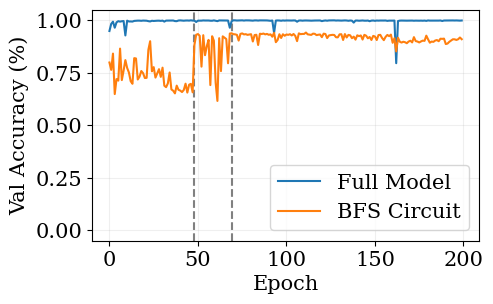

In [34]:
from matplotlib import pyplot as plt
plt.rcParams.update({'font.size': 15, 'font.family': 'serif'})

circuit_accuracies = torch.load(f'metrics/bfs_circuit_{split}_accuracies.pt')
val_accuracy = torch.load(f'checkpoints/val_accs.pt')
fig = plt.figure(figsize=(5,3))
plt.ylim(-.05,1.05)
plt.axvline(x=48, color='gray', linestyle='--')
plt.axvline(x=69, color='gray', linestyle='--')
plt.grid(alpha=0.2)
plt.plot(epochs, val_accuracy[task][:len(epochs)], label='Full Model')
plt.plot(epochs, circuit_accuracies, label='BFS Circuit')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy (%)')
plt.legend()
plt.savefig(f'figures/bfs_circuit_{split}_accuracy.png', bbox_inches='tight', dpi=300)
plt.savefig(f'figures/bfs_circuit_{split}_accuracy.pdf', bbox_inches='tight')
plt.show()